# Computational Statistical Mechanics - pamuduamarasinghe

 1) Exact Harmoinic Function

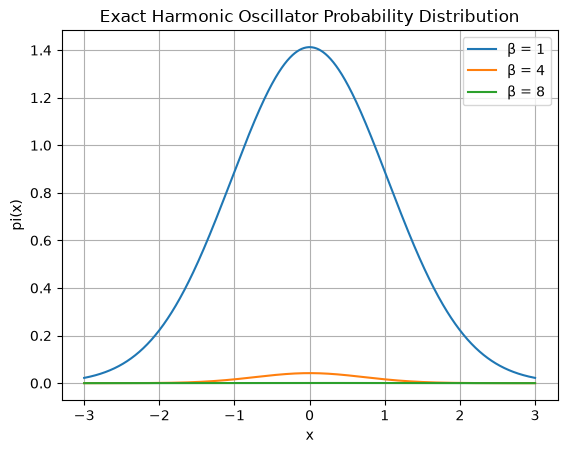

β = 1
sigma = 1.040181
Amplitude = 0.383532
β = 4
sigma = 0.720179
Amplitude = 0.553949
β = 8
sigma = 0.707344
Amplitude = 0.564000


In [5]:
import numpy as np
import matplotlib.pyplot as plt



def exact_diagonal_density_matrix(x, beta):

    sinhB = np.sinh(beta)
    tanhB = np.tanh(beta/2)
    
    prefactor = np.sqrt(1/(2 * np.pi * sinhB))
    return prefactor * np.exp(-x**2 * tanhB)


def exact_solution(x, beta):
    sinhB2 = np.sinh(beta/2)

    return 1/2*sinhB2

def probability (x,beta):
    
    return  exact_diagonal_density_matrix(x, beta) / exact_solution(x, beta)


x = np.linspace(-3, 3, 1000)

beta_values = [1, 4, 8]

for beta in beta_values:
    plt.plot(x, probability (x,beta), label=f"β = {beta}")

plt.xlabel("x")
plt.ylabel("pi(x)")
plt.title("Exact Harmonic Oscillator Probability Distribution") 
plt.legend()
plt.grid() 
plt.show()

beta_values = [1,4,8]

for beta in beta_values:

    sigma = 1 / np.sqrt(2*np.tanh(beta/2))
    amplitude = np.sqrt(np.tanh(beta/2)/np.pi) 
    print(f"β = {beta}")
    print(f"sigma = {sigma:.6f}")
    print(f"Amplitude = {amplitude:.6f}") 


2. Path sampling using Markov-Chain Method.

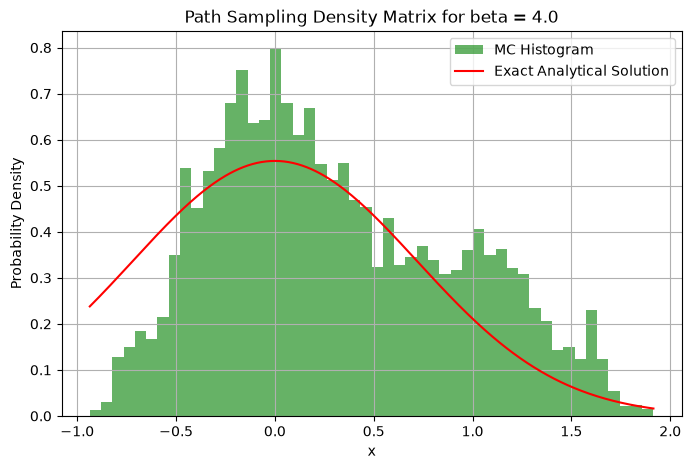

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def rho_free(x1, x2, beta):
    return np.sqrt(1/(2*np.pi*beta)) * np.exp(-(x1-x2)**2/(2*beta) )

N = 20
beta = 4.0
X = [0.0 for i in range(N)]
X0 =[]

delta = beta/N
itr = 100000

for i in range(itr):
    k = random.randint(0, N-1)

    kp = k +1
    km = k -1
    if km < 0:
        km = N-1
    if kp == N:
        kp = 0

    xk = X[k]
    xk1 = xk + random.uniform(-0.1, 0.1)    
    xkp = X[kp]
    xkm = X[km] 

    pia = rho_free(xkm, xk, delta) * rho_free(xk, xkp, delta) * np.exp(-0.5 * delta * xk**2)
    pib = rho_free(xkm, xk1, delta) * rho_free(xk1, xkp, delta) * np.exp(-0.5 * delta * xk1**2)
        
    gamma = pib / pia
        
    
    if random.uniform(0, 1) < gamma:
            X[k] = xk1 
        
    X0.append(X[0])
    
    
plt.figure(figsize=(8, 5))
count, bins, ignored = plt.hist(X0, bins=50, density=True, alpha=0.6, color='g', label='MC Histogram')
    
x_arr = np.linspace(min(bins), max(bins), 500)
exact_variance = 1.0 / (2.0 * np.tanh(beta / 2.0))
exact_rho = (1.0 / np.sqrt(2.0 * np.pi * exact_variance)) * np.exp(-x_arr**2 / (2.0 * exact_variance))
    
plt.plot(x_arr, exact_rho, 'r-', label='Exact Analytical Solution')
plt.title(f'Path Sampling Density Matrix for beta = {beta}')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

3. Direct path sampling for harmonic oscillation.

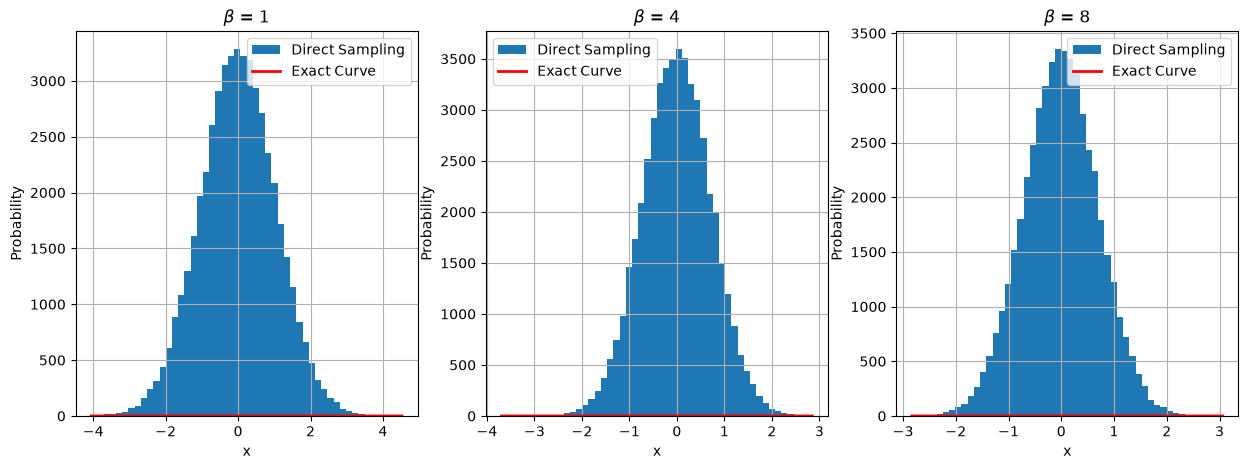

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def direct_path_sampling(beta, N, num_paths):
    delta = beta / N
    X0_samples = []

    sigma_0 = np.sqrt(1.0 / (2.0 * np.tanh(beta / 2.0)))
    
    for _ in range(num_paths):
        path = np.zeros(N)
        path[0] = np.random.normal(0, sigma_0)
        
      
        for k in range(1, N):
    
            rem_steps = N - k
            mean = (path[k-1] * rem_steps + path[0]) / (rem_steps + 1)
            variance = delta * (rem_steps) / (rem_steps + 1)
            
            path[k] = np.random.normal(mean, np.sqrt(variance))
            

        X0_samples.append(path[0])
        
    return np.array(X0_samples)

N = 12
num_paths = 50000
betas = [1, 4, 8]

plt.figure(figsize=(15, 5))

for idx, beta in enumerate(betas):
    X0 = direct_path_sampling(beta, N, num_paths)
    
    plt.subplot(1, 3, idx+1)
    count, bins, _ = plt.hist(X0, bins=50, label='Direct Sampling')
    
 
    x_arr = np.linspace(min(bins), max(bins), 500)
    exact_variance = 1.0 / (2.0 * np.tanh(beta / 2.0))
    exact_rho = (1.0 / np.sqrt(2.0 * np.pi * exact_variance)) * np.exp(-x_arr**2 / (2.0 * exact_variance))
    
    plt.plot(x_arr, exact_rho, 'r-', lw=2, label='Exact Curve')
    plt.title(f'$\\beta$ = {beta}')
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True)

plt.show()